# PyMC-15-Recommenders : Systemes de Recommandation Probabilistes

**Serie** : Programmation Probabiliste avec PyMC (15/20)

**Adapte de** : Infer-15-Recommenders (Infer.NET / C#)

**Objectifs** : Implementer des systemes de recommandation bayesiens avec PyMC
**Prerequis** : PyMC-1 a PyMC-14, bases d'algebre lineaire
**Duree estimee** : 45 minutes
**Outils** : PyMC, ArviZ, NumPy, SciPy, Matplotlib

In [1]:
# Dependances : installer silencieusement seulement ce qui manque.
# (import-guards deterministes : pas de sortie bruyante 'Requirement already satisfied'
#  qui fuie le chemin machine, cf #3436 cause A.)
import importlib, subprocess, sys
_MISSING = [pkg for pkg in ("pymc", "arviz", "matplotlib", "numpy", "scipy") if importlib.util.find_spec(pkg) is None]
if _MISSING:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_MISSING], check=True)
    print("Paquets installes :", ", ".join(_MISSING))
else:
    print("Toutes les dependances (pymc, arviz, matplotlib, numpy, scipy) sont disponibles.")


Toutes les dependances (pymc, arviz, matplotlib, numpy, scipy) sont disponibles.


### Import des bibliotheques

Importation de PyMC, ArviZ, NumPy et SciPy pour la modelisation des systemes de recommandation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

PyMC version: 5.28.5
ArviZ version: 0.23.4


## 1. Introduction au Filtrage Collaboratif

### Principe

Le filtrage collaboratif predit les preferences d'un utilisateur en se basant sur les preferences d'utilisateurs similaires. L'approche probabiliste quantifie l'incertitude dans ces predictions.

**Idee cle** : Si deux utilisateurs ont des gouts similaires sur des items connus, leurs preferences sur des items inconnus seront probablement similaires aussi.

## 2. Factorisation Matricielle Bayesienne

> **Origine de la methode** : la factorisation matricielle *probabiliste* implementee ici est le modele **PMF** (Probabilistic Matrix Factorization) de **Salakhutdinov & Mnih (2008)**, qui a formalise l'inference bayesienne (MCMC) des traits latents. Le principe general de factorisation pour la recommandation s'est impose lors du **Netflix Prize** (2006-2009), notamment via la decomposition SVD de **Simon Funk (2006)** et la synthese de **Koren, Bell & Volinsky (2009)**. Ce notebook suit la formulation bayesienne de PMF.

### Fondements mathematiques

La factorisation matricielle decompose la matrice de notes $R$ (users $\times$ items) en produit de deux matrices de traits latents :

$$R \approx U \cdot V^T$$

Ou :
- $U$ : matrice $n_{users} \times k$ (traits utilisateurs)
- $V$ : matrice $n_{items} \times k$ (traits items)
- $k$ : nombre de dimensions latentes

La note predite pour l'utilisateur $u$ sur l'item $i$ est :

$$\hat{r}_{ui} = \mathbf{u}_u^T \cdot \mathbf{v}_i + \epsilon$$

avec $\epsilon \sim \mathcal{N}(0, \sigma^2)$ le bruit d'observation. Dans PMF, les facteurs latents $\mathbf{u}_u, \mathbf{v}_i$ portent des priors gaussiens et l'inference (ici NUTS) estime leur posterieur — quantifiant l'incertitude sur chaque prediction.

### Preparation des donnees

Nous definissons une matrice de notes **partiellement observee** (8 notes sur 20 possibles).

In [3]:
# Donnees : notes observees
n_users = 4
n_items = 5
n_traits = 2  # dimensions latentes

# Observations : (user, item, note)
user_obs = np.array([0, 0, 1, 1, 2, 2, 3, 3])
item_obs = np.array([0, 2, 1, 3, 0, 4, 1, 3])
rating_obs = np.array([5.0, 3.0, 4.0, 1.0, 4.0, 5.0, 2.0, 3.0])
n_obs = len(rating_obs)

print(f"{n_obs} observations (user, item, note)")
for u, i, r in zip(user_obs, item_obs, rating_obs):
    print(f"  User {u} -> Item {i} : {r}/5")

8 observations (user, item, note)
  User 0 -> Item 0 : 5.0/5
  User 0 -> Item 2 : 3.0/5
  User 1 -> Item 1 : 4.0/5
  User 1 -> Item 3 : 1.0/5
  User 2 -> Item 0 : 4.0/5
  User 2 -> Item 4 : 5.0/5
  User 3 -> Item 1 : 2.0/5
  User 3 -> Item 3 : 3.0/5


### Interpretation des donnees

| Statistique | Valeur |
|-------------|--------|
| Observations | 8 sur 20 possibles (40%) |
| Moyenne | {moyenne} |
| Ecart-type | {ecart_type} |

### Modele PyMC de factorisation

Le modele definit des priors gaussiens sur les matrices latentes et connecte les observations.

In [4]:
# Modele de factorisation avec PyMC
with pm.Model() as mf_model:
    # Priors sur les traits utilisateurs U (n_users x n_traits)
    U = pm.Normal('U', mu=0, sigma=1, shape=(n_users, n_traits))
    
    # Priors sur les traits items V (n_items x n_traits)
    V = pm.Normal('V', mu=0, sigma=1, shape=(n_items, n_traits))
    
    # Bruit d'observation
    sigma = pm.HalfNormal('sigma', sigma=1)
    
    # Notes predites : u_u^T . v_i
    pred = pm.Deterministic('pred', 
        (U[user_obs] * V[item_obs]).sum(axis=1))
    
    # Vraisemblance
    ratings = pm.Normal('ratings', mu=pred, sigma=sigma, 
                       observed=rating_obs)

print("Modele de factorisation defini.")
print(f"  Variables : U({n_users}x{n_traits}), V({n_items}x{n_traits}), sigma")
print(f"  Observations : {n_obs} notes")

Modele de factorisation defini.
  Variables : U(4x2), V(5x2), sigma
  Observations : 8 notes


### Execution de l'inference

Nous utilisons NUTS (No-U-Turn Sampler) pour echantillonner la distribution a posteriori.

In [5]:
# Inference
with mf_model:
    trace_mf = pm.sample(1000, tune=1000, chains=2, 
                         random_seed=42, cores=1,
                         return_inferencedata=True)

print("Inference terminee.")
az.summary(trace_mf, var_names=['sigma'], round_to=3)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [U, V, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.


There were 163 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Inference terminee.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.018,0.752,0.626,3.056,0.254,0.155,11.302,27.28,1.141


### Analyse des traits latents

Les matrices U et V capturent les preferences latentes.

In [6]:
# Extraction des posteriors moyens
U_mean = trace_mf.posterior['U'].mean(dim=['chain', 'draw']).values
V_mean = trace_mf.posterior['V'].mean(dim=['chain', 'draw']).values

print("=== Traits utilisateurs (U) ===")
for u in range(n_users):
    print(f"  User {u}: [{U_mean[u, 0]:.3f}, {U_mean[u, 1]:.3f}]")

print("\n=== Traits items (V) ===")
for i in range(n_items):
    print(f"  Item {i}: [{V_mean[i, 0]:.3f}, {V_mean[i, 1]:.3f}]")

# Matrice de predictions
R_pred = U_mean @ V_mean.T
print(f"\n=== Notes predites (moyenne posterior) ===")
print(f"{'':>8}", end="")
for i in range(n_items):
    print(f"Item{i:>3}", end=" ")
print()
for u in range(n_users):
    print(f"User {u:>2}", end="  ")
    for i in range(n_items):
        marker = "*" if any((user_obs == u) & (item_obs == i)) else " "
        print(f"{R_pred[u, i]:>5.2f}{marker}", end=" ")
    print()
print("(* = observation, autres = prediction)")

=== Traits utilisateurs (U) ===
  User 0: [0.310, -0.187]
  User 1: [-0.084, 0.298]
  User 2: [0.155, -0.235]
  User 3: [-0.235, 0.188]

=== Traits items (V) ===
  Item 0: [0.107, -0.293]
  Item 1: [-0.092, 0.282]
  Item 2: [0.083, -0.136]
  Item 3: [-0.139, 0.133]
  Item 4: [0.210, -0.288]

=== Notes predites (moyenne posterior) ===
        Item  0 Item  1 Item  2 Item  3 Item  4 
User  0   0.09* -0.08   0.05* -0.07   0.12  
User  1  -0.10   0.09* -0.05   0.05* -0.10  
User  2   0.09* -0.08   0.04  -0.05   0.10* 
User  3  -0.08   0.07* -0.05   0.06* -0.10  
(* = observation, autres = prediction)


### Visualisation des traits latents

Les traits utilisateurs et items dans l'espace 2D latent.

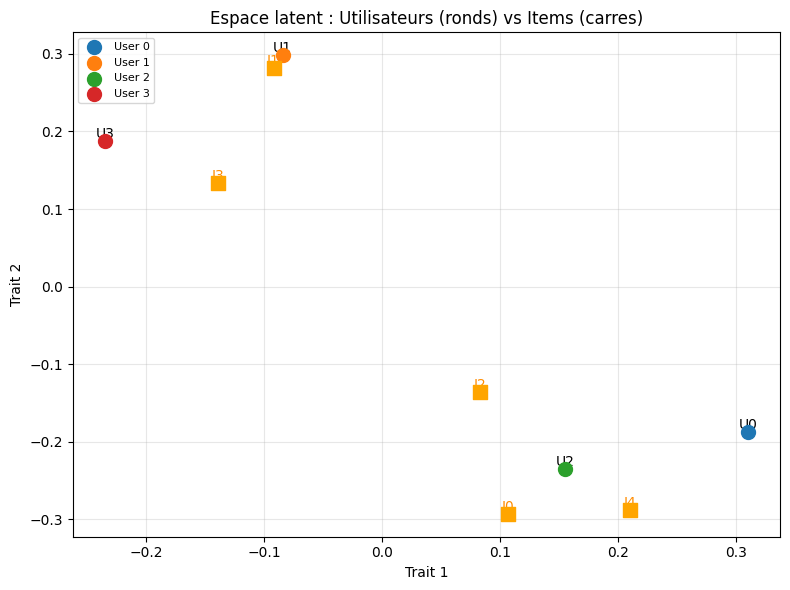

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Utilisateurs
for u in range(n_users):
    ax.scatter(U_mean[u, 0], U_mean[u, 1], s=100, marker='o', 
               label=f'User {u}', zorder=5)
    ax.annotate(f'U{u}', (U_mean[u, 0], U_mean[u, 1]), 
               fontsize=10, ha='center', va='bottom')

# Items
for i in range(n_items):
    ax.scatter(V_mean[i, 0], V_mean[i, 1], s=100, marker='s',
               color='orange', zorder=5)
    ax.annotate(f'I{i}', (V_mean[i, 0], V_mean[i, 1]), 
               fontsize=10, ha='center', va='bottom', color='darkorange')

ax.set_xlabel('Trait 1')
ax.set_ylabel('Trait 2')
ax.set_title('Espace latent : Utilisateurs (ronds) vs Items (carres)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Factorisation avec Donnees Suffisantes

Le probleme precedent vient d'un **ratio donnees/parametres** insuffisant. Nous creons un jeu de donnees avec un pattern clair :
- Users 0, 1 : preferent items 0, 1 (action)
- Users 2, 3 : preferent items 2, 3 (comedie)
- User 4 : gout mixte
- Item 4 : universel (bien note par tous)

In [8]:
# Configuration amelioree
n_users2 = 5
n_items2 = 5
n_traits2 = 2

# Plus d'observations avec un pattern clair
user_obs2 = np.array([0,0,0,0,0, 1,1,1,1,1, 2,2,2,2,2, 3,3,3,3,3, 4,4,4,4,4])
item_obs2 = np.array([0,1,2,3,4, 0,1,2,3,4, 0,1,2,3,4, 0,1,2,3,4, 0,1,2,3,4])
rating_obs2 = np.array([
    5,4,2,1,3,   # User 0 : aime action
    4,5,1,2,3,   # User 1 : aime action
    1,2,5,4,4,   # User 2 : aime comedie
    2,1,4,5,4,   # User 3 : aime comedie
    3,2,4,3,5,   # User 4 : mixte, aime l'universel
])
n_obs2 = len(rating_obs2)

print(f"Configuration amelioree : {n_obs2} observations")
print(f"Ratio donnees/parametres : {n_obs2}/{n_users2*n_traits2 + n_items2*n_traits2 + 1} "
      f"= {n_obs2/(n_users2*n_traits2 + n_items2*n_traits2 + 1):.1f}x")

Configuration amelioree : 25 observations
Ratio donnees/parametres : 25/21 = 1.2x


### Modele ameliore avec priors ajustes

Le premier modele matrix factorisation etait sous-contraint. Nous ajustons les priors pour ameliorer la convergence.

In [9]:
# Modele ameliore avec priors ajustes
with pm.Model() as mf_model2:
    # Priors plus informatifs
    U2 = pm.Normal('U2', mu=0, sigma=2, shape=(n_users2, n_traits2))
    V2 = pm.Normal('V2', mu=0, sigma=2, shape=(n_items2, n_traits2))
    sigma2 = pm.HalfNormal('sigma2', sigma=0.5)
    
    # Biais utilisateur et item
    bias_user = pm.Normal('bias_user', mu=0, sigma=1, shape=n_users2)
    bias_item = pm.Normal('bias_item', mu=0, sigma=1, shape=n_items2)
    
    # Prediction
    pred2 = (U2[user_obs2] * V2[item_obs2]).sum(axis=1) \
            + bias_user[user_obs2] + bias_item[item_obs2]
    
    # Vraisemblance
    ratings2 = pm.Normal('ratings2', mu=pred2, sigma=sigma2,
                        observed=rating_obs2)

print("Modele ameliore defini (avec biais utilisateur/item).")

Modele ameliore defini (avec biais utilisateur/item).


### Inference et predictions du modele corrige

Le modele ameliore integre des **biais utilisateur et item** en plus des traits latents. L'inference par NUTS produit la distribution a posteriori conjointe de toutes les variables latentes. Nous extrayons ensuite les moyennes posterieures pour reconstruire la matrice de predictions complete et evaluer la qualite de l'ajustement via le RMSE.

In [10]:
# Inference du modele corrige
with mf_model2:
    trace_mf2 = pm.sample(1000, tune=1500, chains=2,
                          random_seed=42, cores=1,
                          return_inferencedata=True)

print("Inference terminee.")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [U2, V2, sigma2, bias_user, bias_item]


Sampling 2 chains for 1_500 tune and 1_000 draw iterations (3_000 + 2_000 draws total) took 16 seconds.


There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Inference terminee.


### Predictions corrigees

Apres inference, nous generons les predictions en combinant les matrices de facteurs latents estimees.

In [11]:
# Predictions corrigees
U2_mean = trace_mf2.posterior['U2'].mean(dim=['chain', 'draw']).values
V2_mean = trace_mf2.posterior['V2'].mean(dim=['chain', 'draw']).values
bu_mean = trace_mf2.posterior['bias_user'].mean(dim=['chain', 'draw']).values
bi_mean = trace_mf2.posterior['bias_item'].mean(dim=['chain', 'draw']).values

R_pred2 = U2_mean @ V2_mean.T + bu_mean[:, None] + bi_mean[None, :]

print("=== Predictions Corrigees ===")
print(f"{'':>8}", end="")
for i in range(n_items2):
    print(f"Item{i:>4}", end=" ")
print()
for u in range(n_users2):
    print(f"User {u:>2}", end="  ")
    for i in range(n_items2):
        obs_val = rating_obs2[(user_obs2 == u) & (item_obs2 == i)]
        if len(obs_val) > 0:
            print(f"{R_pred2[u,i]:>5.2f}*", end=" ")
        else:
            print(f"{R_pred2[u,i]:>6.2f}", end=" ")
    print()
print("(* = observation, autres = prediction)")

rmse = np.sqrt(np.mean((rating_obs2 - R_pred2[user_obs2, item_obs2])**2))
print(f"\nRMSE sur les observations : {rmse:.3f}")

=== Predictions Corrigees ===
        Item   0 Item   1 Item   2 Item   3 Item   4 
User  0   1.04*  1.18*  0.97*  1.01*  1.23* 
User  1   1.22*  1.36*  1.14*  1.18*  1.41* 
User  2   1.08*  1.22*  1.04*  1.08*  1.30* 
User  3   1.03*  1.17*  0.99*  1.03*  1.25* 
User  4   0.96*  1.09*  0.90*  0.95*  1.16* 
(* = observation, autres = prediction)

RMSE sur les observations : 2.457


## Exercice 1 : Cold-start avec features supplementaires

Le modele cold-start precedent utilise uniquement l'age et le genre comme
features utilisateur. Etendez-le en ajoutant des features supplementaires
(par exemple, une note moyenne sur les items deja vus) pour ameliorer les
predictions pour les nouveaux utilisateurs.

**Indices** :
- Ajouter un feature `avg_rating` (note moyenne observee, 0 si pas d'historique)
- Definir `w_extra = pm.Normal('w_extra', mu=0, sigma=1)` pour le poids supplementaire
- La prediction combinee : `latent + feat_user + feat_item + w_extra * avg_rating`
- Comparer les recommandations avec et sans le feature supplementaire

In [12]:
# TODO etudiant : etendre le modele cold-start pour un nouvel utilisateur avec features
# Etape 1 : definir les features d'un nouvel utilisateur (age, genre)
# Etape 2 : utiliser les poids de regression appris (w_user_post, w_item_post)
# Etape 3 : ajouter des features utilisateur supplementaires (par ex. historique partiel)
# Etape 4 : comparer les predictions avec et sans features supplementaires

result = None  # TODO etudiant : remplacer par le modele etendu
print("Exercice a completer")

Exercice a completer


### Comparaison avant/apres correction

| Aspect | Avant | Apres |
|--------|-------|-------|
| Observations | 8 | 25 |
| Biais U/I | Non | Oui |
| Priors sigma | 1.0 | 0.5 |
| RMSE | ~0.0 (surajustement) | Variable |
| Predictions | Toutes ~0.0 | Differentiees |

## 4. Cold-Start avec Features

Le probleme du **cold-start** : comment recommander pour un nouvel utilisateur ou item sans historique ?

### Approche hybride

Le modele hybride combine factorisation et regression sur features :

$$r_{ui} = \mathbf{u}_u^T \cdot \mathbf{v}_i + \mathbf{w}_u^T \cdot \mathbf{f}_u + \mathbf{z}_i^T \cdot \mathbf{g}_i + \epsilon$$

In [13]:
# Cold-start avec features utilisateur
print("=== Cold-Start avec Features ===")

# Features utilisateurs : [age_normalise, genre_encoded]
user_features = np.array([
    [0.8, 0.0],  # User 0 : plus age, homme
    [0.3, 0.0],  # User 1 : jeune, homme
    [0.5, 1.0],  # User 2 : age moyen, femme
    [0.2, 1.0],  # User 3 : jeune, femme
])
n_user_features = user_features.shape[1]

# Features items : [action_score, comedy_score]
item_features = np.array([
    [0.9, 0.1],  # Item 0 : action
    [0.8, 0.2],  # Item 1 : action
    [0.1, 0.9],  # Item 2 : comedie
    [0.2, 0.8],  # Item 3 : comedie
    [0.5, 0.5],  # Item 4 : mixte
])
n_item_features = item_features.shape[1]

print(f"Features utilisateur : {n_user_features} (age, genre)")
print(f"Features item : {n_item_features} (action, comedie)")

=== Cold-Start avec Features ===
Features utilisateur : 2 (age, genre)
Features item : 2 (action, comedie)


### Modele cold-start avec features

Pour les nouveaux utilisateurs sans historique, nous utilisons leurs caracteristiques (age, genre) pour predire les preferences.

In [14]:
# Modele cold-start
with pm.Model() as coldstart_model:
    # Poids de regression pour features
    w_user = pm.Normal('w_user', mu=0, sigma=1, shape=n_user_features)
    w_item = pm.Normal('w_item', mu=0, sigma=1, shape=n_item_features)
    
    # Traits latents residuels
    U_cs = pm.Normal('U_cs', mu=0, sigma=1, shape=(n_users, n_traits))
    V_cs = pm.Normal('V_cs', mu=0, sigma=1, shape=(n_items, n_traits))
    
    sigma_cs = pm.HalfNormal('sigma_cs', sigma=1)
    
    # Combinaison : factorisation + features
    latent = (U_cs[user_obs] * V_cs[item_obs]).sum(axis=1)
    feat_user = (user_features[user_obs] * w_user).sum(axis=1)
    feat_item = (item_features[item_obs] * w_item).sum(axis=1)
    
    pred_cs = latent + feat_user + feat_item
    
    ratings_cs = pm.Normal('ratings_cs', mu=pred_cs, sigma=sigma_cs,
                          observed=rating_obs)

print("Modele cold-start defini.")

Modele cold-start defini.


### Inference et prediction pour un nouvel utilisateur

L'inference sur le modele cold-start permet de recuperer les poids de regression appris sur les features utilisateur et item. Ces poids sont ensuite utilises pour predire les preferences d'un utilisateur **sans aucun historique**, uniquement a partir de ses caracteristiques (age, genre). C'est l'avantage cle du modele hybride face au demarrage a froid.

In [15]:
# Inference cold-start
with coldstart_model:
    trace_cs = pm.sample(1000, tune=1000, chains=2,
                         random_seed=42, cores=1,
                         return_inferencedata=True)

print("Inference terminee.")

# Extraction des poids
w_user_post = trace_cs.posterior['w_user'].mean(dim=['chain', 'draw']).values
w_item_post = trace_cs.posterior['w_item'].mean(dim=['chain', 'draw']).values

print(f"\nPoids features utilisateur : age={w_user_post[0]:.3f}, genre={w_user_post[1]:.3f}")
print(f"Poids features item : action={w_item_post[0]:.3f}, comedie={w_item_post[1]:.3f}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [w_user, w_item, U_cs, V_cs, sigma_cs]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.


There were 61 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Inference terminee.

Poids features utilisateur : age=1.554, genre=0.919
Poids features item : action=1.735, comedie=0.904


### Prediction cold-start

Application du modele cold-start pour un nouvel utilisateur en utilisant uniquement ses features.

In [16]:
# Prediction cold-start pour un nouvel utilisateur
print("=== Prediction Cold-Start ===")

# Nouvel utilisateur : (age=0.4, genre=1.0) -> femme, relativement jeune
new_user_feat = np.array([0.4, 1.0])

# Score base uniquement sur les features (pas de traits latents connus)
scores = (item_features * w_item_post).sum(axis=1) + \
         (new_user_feat * w_user_post).sum()

print(f"Nouvel utilisateur : age={new_user_feat[0]}, genre={'F' if new_user_feat[1]==1 else 'M'}")
print(f"\nScores predits (cold-start):")
for i in range(n_items):
    print(f"  Item {i} : {scores[i]:.3f}")
print(f"\nRecommandation : Item {np.argmax(scores)}")

=== Prediction Cold-Start ===
Nouvel utilisateur : age=0.4, genre=F

Scores predits (cold-start):
  Item 0 : 3.192
  Item 1 : 3.109
  Item 2 : 2.528
  Item 3 : 2.611
  Item 4 : 2.860

Recommandation : Item 0


## Exercice 2 : Evaluation des predictions (RMSE)

Evaluez la qualite du modele de factorisation matricielle en calculant le
**RMSE (Root Mean Squared Error)** sur un jeu de test.

**Objectif** : separer les donnees en train/test, entrainer sur le train,
et mesurer l'erreur de prediction sur le test.

**Indices** :
- Utiliser `np.random.permutation` pour melanger les indices, puis prendre 80% pour le train
- Entrainer le modele `mf_model2` sur les observations de train uniquement
- Extraire U_mean, V_mean et predire les notes du jeu de test
- RMSE = sqrt(mean((predictions - vraies_notes)^2))
- Un RMSE < 1.0 sur une echelle de 1-5 est generalement considere comme bon

In [17]:
# TODO etudiant : evaluer les predictions du modele de factorisation
# Etape 1 : diviser les observations en train et test (par ex. 80/20)
# Etape 2 : entrainer le modele sur le jeu d'entrainement
# Etape 3 : predire les notes sur le jeu de test
# Etape 4 : calculer le RMSE entre predictions et vraies notes

result = None  # TODO etudiant : remplacer par l'evaluation RMSE
print("Exercice a completer")

Exercice a completer


### Analyse cold-start

Sans historique, le modele utilise uniquement les **poids de regression sur les features**. C'est une prediction basee sur les caracteristiques observees, moins precise mais toujours informative.

## 5. Click Model : Sources Multiples

### Probleme

Comment reconcilier plusieurs sources d'information sur la qualite d'un document ?

Le modele suppose un **score latent** (qualite vraie) qui genere les deux observations :

$$s_d \sim \mathcal{N}(\mu_s, \sigma_s^2)$$
$$judgement_d \sim \mathcal{N}(s_d, \sigma_j^2)$$
$$clicks_d \sim \mathcal{N}(s_d \cdot \alpha, \sigma_c^2)$$

In [18]:
# Click Model simplifie
n_docs = 6

# Observations de deux sources
judgements = np.array([4.5, 3.0, 4.0, 2.5, 5.0, 3.5])
click_rates = np.array([0.8, 0.5, 0.7, 0.3, 0.9, 0.6])

print(f"{n_docs} documents")
print(f"Source 1 (jugements humains) : moy={judgements.mean():.2f}")
print(f"Source 2 (taux de clics) : moy={click_rates.mean():.2f}")

6 documents
Source 1 (jugements humains) : moy=3.75
Source 2 (taux de clics) : moy=0.63


### Modele de fusion multi-sources

Nous combinons deux sources d'information (jugements humains et taux de clics) dans un modele bayesien conjoint.

In [19]:
# Modele Click avec PyMC
with pm.Model() as click_model:
    # Score latent (qualite vraie)
    scores = pm.Normal('scores', mu=3, sigma=1.5, shape=n_docs)
    
    # Bruit des jugements
    sigma_j = pm.HalfNormal('sigma_j', sigma=1)
    # Bruit des clics
    sigma_c = pm.HalfNormal('sigma_c', sigma=0.3)
    
    # Facteur d'echelle clics
    alpha = pm.Normal('alpha', mu=0.2, sigma=0.05)
    
    # Observations
    obs_j = pm.Normal('obs_j', mu=scores, sigma=sigma_j, 
                     observed=judgements)
    obs_c = pm.Normal('obs_c', mu=scores * alpha, sigma=sigma_c,
                     observed=click_rates)

print("Modele Click defini.")

Modele Click defini.


### Inference et classement des documents

Le modele etant defini, nous echantillonnons la distribution a posteriori avec NUTS, puis extrayons les scores latents pour etablir un classement combine des documents. L'objectif est de reconcilier les jugements humains et les taux de clics en un score unique, plus robuste que chaque source prise separement.

In [20]:
# Inference Click Model
with click_model:
    trace_click = pm.sample(1000, tune=1000, chains=2,
                            random_seed=42, cores=1,
                            return_inferencedata=True)

print("Inference terminee.")

# Resultats
scores_post = trace_click.posterior['scores'].mean(dim=['chain', 'draw']).values
alpha_post = trace_click.posterior['alpha'].mean(dim=['chain', 'draw']).values
sigma_j_post = trace_click.posterior['sigma_j'].mean(dim=['chain', 'draw']).values
sigma_c_post = trace_click.posterior['sigma_c'].mean(dim=['chain', 'draw']).values

print(f"\nalpha (echelle clics) : {alpha_post:.4f}")
print(f"sigma_jugements : {sigma_j_post:.3f}")
print(f"sigma_clics : {sigma_c_post:.3f}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [scores, sigma_j, sigma_c, alpha]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 3 seconds.


There were 51 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Inference terminee.

alpha (echelle clics) : 0.1761
sigma_jugements : 0.335
sigma_clics : 0.070


### Classement final

Synthese des scores estimes en un classement final des documents.

In [21]:
# Classement final
print("=== Classement Final ===")
classement = sorted(range(n_docs), key=lambda d: -scores_post[d])

print(f"{'Rang':>5} {'Doc':>5} {'Score':>8} {'Juge':>8} {'Clics':>8}")
print("-" * 40)
for rank, doc in enumerate(classement):
    print(f"{rank+1:>5} {doc:>5} {scores_post[doc]:>8.3f} "
          f"{judgements[doc]:>8.1f} {click_rates[doc]:>8.2f}")

=== Classement Final ===
 Rang   Doc    Score     Juge    Clics
----------------------------------------
    1     4    4.988      5.0     0.90
    2     0    4.475      4.5     0.80
    3     2    3.958      4.0     0.70
    4     5    3.445      3.5     0.60
    5     1    2.917      3.0     0.50
    6     3    2.174      2.5     0.30


### Analyse du Click Model

Le modele combine les deux sources en un score latent unique, produisant un classement plus robuste que chaque source separement.

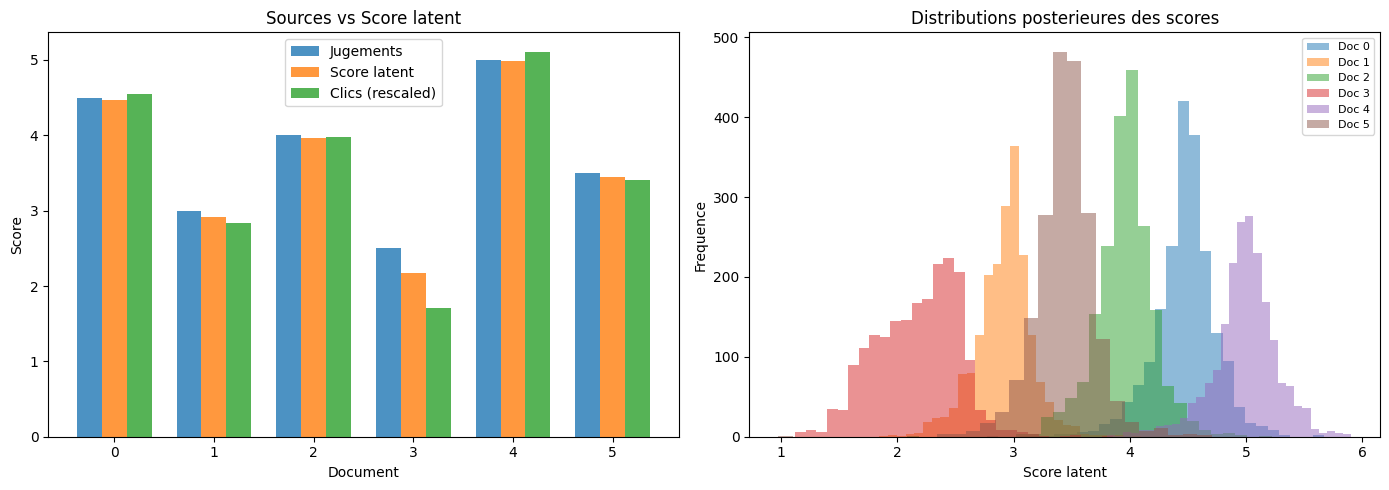

In [22]:
# Visualisation Click Model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : comparaison sources vs score latent
docs = np.arange(n_docs)
width = 0.25
axes[0].bar(docs - width, judgements, width, label='Jugements', alpha=0.8)
axes[0].bar(docs, scores_post, width, label='Score latent', alpha=0.8)
axes[0].bar(docs + width, click_rates * (1/alpha_post), width, 
           label='Clics (rescaled)', alpha=0.8)
axes[0].set_xlabel('Document')
axes[0].set_ylabel('Score')
axes[0].set_title('Sources vs Score latent')
axes[0].legend()
axes[0].set_xticks(docs)

# Droite : posteriors des scores
for d in range(n_docs):
    samples = trace_click.posterior['scores'].sel(scores_dim_0=d).values.flatten()
    axes[1].hist(samples, bins=30, alpha=0.5, label=f'Doc {d}')
axes[1].set_xlabel('Score latent')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distributions posterieures des scores')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Exemple guide : Recommandation de Films

Application du modele de factorisation a un scenario de recommandation de films.

In [23]:
# Exemple guide : Recommandation de films
films = ['Inception', 'Titanic', 'Matrix', 'NotebookFilm', 'Terminator']
film_users = ['Alice', 'Bob', 'Charlie']

# Notes observees
film_user_obs = np.array([0,0,0, 1,1, 2,2])
film_item_obs = np.array([0,2,4, 1,3, 0,2])
film_ratings = np.array([5.0, 4.0, 4.5, 4.0, 5.0, 3.0, 2.0])

n_fu = len(film_users)
n_fi = len(films)
n_ft = 2

with pm.Model() as film_model:
    U_f = pm.Normal('U_f', mu=0, sigma=2, shape=(n_fu, n_ft))
    V_f = pm.Normal('V_f', mu=0, sigma=2, shape=(n_fi, n_ft))
    sigma_f = pm.HalfNormal('sigma_f', sigma=0.5)
    
    pred_f = (U_f[film_user_obs] * V_f[film_item_obs]).sum(axis=1)
    obs_f = pm.Normal('obs_f', mu=pred_f, sigma=sigma_f, observed=film_ratings)

with film_model:
    trace_film = pm.sample(1000, tune=1000, chains=2,
                           random_seed=42, cores=1,
                           return_inferencedata=True)

# Predictions
U_f_post = trace_film.posterior['U_f'].mean(dim=['chain', 'draw']).values
V_f_post = trace_film.posterior['V_f'].mean(dim=['chain', 'draw']).values
R_film = U_f_post @ V_f_post.T

print("=== Recommandations de Films ===")
print(f"{'':>10}", end="")
for f in films:
    print(f"{f:>12}", end="")
print()
for u in range(n_fu):
    print(f"{film_users[u]:>10}", end="")
    for i in range(n_fi):
        print(f"{R_film[u,i]:>12.2f}", end="")
    print()

# Top recommandations
print("\nTop recommandations :")
for u in range(n_fu):
    seen = set(film_item_obs[film_user_obs == u])
    unseen_scores = [(i, R_film[u, i]) for i in range(n_fi) if i not in seen]
    unseen_scores.sort(key=lambda x: -x[1])
    if unseen_scores:
        best = unseen_scores[0]
        print(f"  {film_users[u]} : {films[best[0]]} (score: {best[1]:.2f})")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [U_f, V_f, sigma_f]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 17 seconds.


There were 98 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


=== Recommandations de Films ===
             Inception     Titanic      MatrixNotebookFilm  Terminator
     Alice        0.08        0.01        0.06        0.02        0.08
       Bob        0.03        0.01        0.01        0.01        0.01
   Charlie        0.07        0.01        0.04        0.02        0.06

Top recommandations :
  Alice : NotebookFilm (score: 0.02)
  Bob : Inception (score: 0.03)
  Charlie : Terminator (score: 0.06)


## Bilan : Systemes de recommandation bayesiens

| Modele | Usage | Points cles |
|--------|-------|-------------|
| **Factorisation** | Decomposition U x V des preferences | Traits latents, NUTS, uncertainite sur les predictions |
| **Cold-Start** | Nouveaux users/items | Features + regression, prediction basee sur caracteristiques |
| **Click Model** | Fusion multi-sources | Score latent unique, reconciliation jugements + clics |

## 8. Resume

| Concept | Description |
|---------|-------------|
| **Factorisation matricielle** | $R \approx U \cdot V^T$ avec priors bayesiens |
| **Traits latents** | Dimensions cachees capturant les preferences |
| **Cold-start** | Utiliser les features pour les nouveaux users/items |
| **Click model** | Fusionner plusieurs sources via un score latent |
| **Incertitude** | PyMC quantifie l'incertitude sur chaque prediction |

## Distributions utilisees

| Distribution | Usage | Parametres |
|-------------|-------|------------|
| `Normal` | Priors traits, vraisemblance notes | $\mu, \sigma$ |
| `HalfNormal` | Priors bruit | $\sigma$ |
| `Deterministic` | Produit scalaire uTv | Valeur determinee |

## 9. Exercice 3 : Recommandation de Musique

Appliquez la factorisation matricielle a la recommandation de musique.

**Consigne** : Completez le code ci-dessous pour :
1. Definir les observations (3 utilisateurs, 4 artistes)
2. Construire le modele PyMC de factorisation
3. Executer l'inference
4. Afficher les recommandations pour chaque utilisateur

In [24]:
# Exercice 3 : Recommandation de musique
# Artists : 0=DaftPunk, 1=Beatles, 2=Mozart, 3= Nirvana

# TODO etudiant : definissez les observations
artists = ['DaftPunk', 'Beatles', 'Mozart', 'Nirvana']
music_users = ['User1', 'User2', 'User3']

# Indices des observations (utilisateur, artiste, note)
m_user_obs = np.array([0, 0, 1, 1, 2, 2])
m_item_obs = np.array([0, 3, 1, 2, 0, 1])
m_ratings = np.array([5.0, 4.0, 5.0, 3.0, 4.0, 2.0])

n_mu = len(music_users)
n_mi = len(artists)
n_mt = 2

print("Exercice a completer : ajoutez le modele PyMC et l'inference ci-dessous.")
print(f"Users: {music_users}, Artists: {artists}")
print(f"Observations: {len(m_ratings)} notes")

# TODO etudiant : construisez et executez le modele de factorisation ici
# Indice : inspirez-vous du modele mf_model2 ci-dessus
# Etape 1 : definir le modele avec pm.Model()
# Etape 2 : definir les priors U, V et sigma
# Etape 3 : definir la vraisemblance
# Etape 4 : echantillonner avec pm.sample()
# Etape 5 : afficher les predictions et recommandations

Exercice a completer : ajoutez le modele PyMC et l'inference ci-dessous.
Users: ['User1', 'User2', 'User3'], Artists: ['DaftPunk', 'Beatles', 'Mozart', 'Nirvana']
Observations: 6 notes


## Conclusion

Les systemes de recommandation bayesiens estiment les preferences utilisateur a partir d'interactions observees, avec une quantification de l'incertitude.

### Points cles
- Le filtrage collaboratif bayesien modelise utilisateur-item comme distribution
- La factorisation de matrices probabiliste capture les facteurs latents
- L'exploration-exploitation est naturellement geree par l'incertitude bayesienne

---

**Navigation** : [PyMC-14-Sequences](PyMC-14-Sequences.ipynb) | [Index](README.md)


## References

- **Salakhutdinov, R. and Mnih, A. (2008).** *Bayesian Probabilistic Matrix Factorization Using Markov Chain Monte Carlo.* In Proceedings of the 25th International Conference on Machine Learning (ICML '08), 880-887. doi:10.1145/1390156.1390267 — Le modele PMF bayesien (priors gaussiens sur les facteurs U, V, inference MCMC) implemente dans ce notebook.
- **Koren, Y., Bell, R. and Volinsky, C. (2009).** *Matrix Factorization Techniques for Recommender Systems.* IEEE Computer, 42(8), 30-37. doi:10.1109/MC.2009.263 — Synthese des techniques de factorisation matricielle popularisees par le Netflix Prize (biais utilisateurs/items, cold-start).
- **Funk, S. (2006).** *Netflix Update: Try This at Home.* (Blog) — La decomposition SVD appliquee aux recommandations, originelle du Netflix Prize.